# Exploración de Datos — Ames Housing

**Materia:** Data Analysis  
**Sección:** Análisis Exploratorio de Datos (EDA)

En este notebook se realiza la exploración de las variables numéricas del conjunto de datos Ames Housing mediante distribuciones, curvas de densidad y análisis de correlación de Pearson y Spearman.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
df.shape

(2930, 82)

In [4]:
columnas_numericas = df.select_dtypes(include=np.number).columns.tolist()

print("Cantidad de variables numéricas:", len(columnas_numericas))
columnas_numericas

Cantidad de variables numéricas: 39


['Order',
 'PID',
 'MS SubClass',
 'Lot Frontage',
 'Lot Area',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Mas Vnr Area',
 'BsmtFin SF 1',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'TotRms AbvGrd',
 'Fireplaces',
 'Garage Yr Blt',
 'Garage Cars',
 'Garage Area',
 'Wood Deck SF',
 'Open Porch SF',
 'Enclosed Porch',
 '3Ssn Porch',
 'Screen Porch',
 'Pool Area',
 'Misc Val',
 'Mo Sold',
 'Yr Sold',
 'SalePrice']

In [5]:
columnas_eda = [
    columna for columna in columnas_numericas
    if columna not in ["Order", "PID"]
]

print("Variables numéricas para el EDA:", len(columnas_eda))
columnas_eda

Variables numéricas para el EDA: 37


['MS SubClass',
 'Lot Frontage',
 'Lot Area',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Mas Vnr Area',
 'BsmtFin SF 1',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'TotRms AbvGrd',
 'Fireplaces',
 'Garage Yr Blt',
 'Garage Cars',
 'Garage Area',
 'Wood Deck SF',
 'Open Porch SF',
 'Enclosed Porch',
 '3Ssn Porch',
 'Screen Porch',
 'Pool Area',
 'Misc Val',
 'Mo Sold',
 'Yr Sold',
 'SalePrice']

In [6]:
from pathlib import Path

carpeta_figuras = Path("figuras")
carpeta_figuras.mkdir(exist_ok=True)

print("Carpeta creada:", carpeta_figuras)

Carpeta creada: figuras


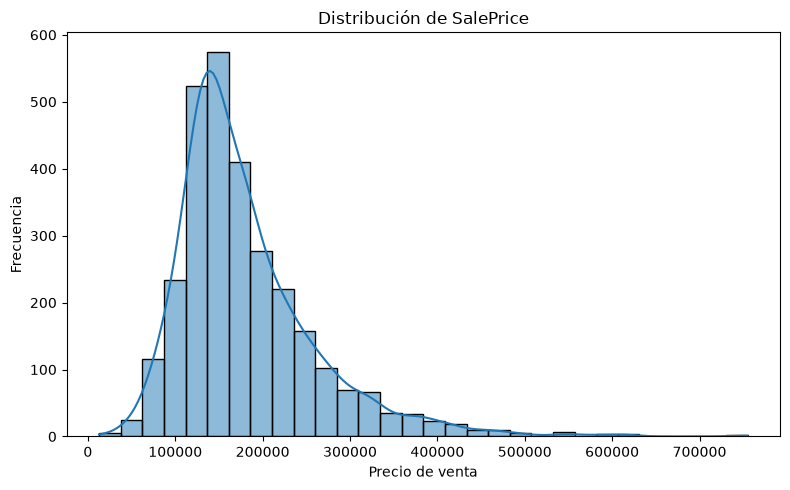

In [7]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="SalePrice",
    bins=30,
    kde=True
)

plt.title("Distribución de SalePrice")
plt.xlabel("Precio de venta")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("figuras/distribucion_SalePrice.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
for columna in columnas_eda:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=columna,
        bins=30,
        kde=True
    )

    plt.title(f"Distribución de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Frecuencia")

    plt.tight_layout()

    # Crear un nombre de archivo válido
    nombre_archivo = columna.replace(" ", "_").replace("/", "_")

    plt.savefig(
        carpeta_figuras / f"distribucion_{nombre_archivo}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print("Gráficas generadas:", len(columnas_eda))

Gráficas generadas: 37


In [9]:
archivos_distribucion = list(carpeta_figuras.glob("distribucion_*.png"))

print("Archivos de distribución guardados:", len(archivos_distribucion))

Archivos de distribución guardados: 37


In [10]:
correlacion_pearson = df[columnas_eda].corr(method="pearson")
correlacion_spearman = df[columnas_eda].corr(method="spearman")

print("Dimensión Pearson:", correlacion_pearson.shape)
print("Dimensión Spearman:", correlacion_spearman.shape)

Dimensión Pearson: (37, 37)
Dimensión Spearman: (37, 37)


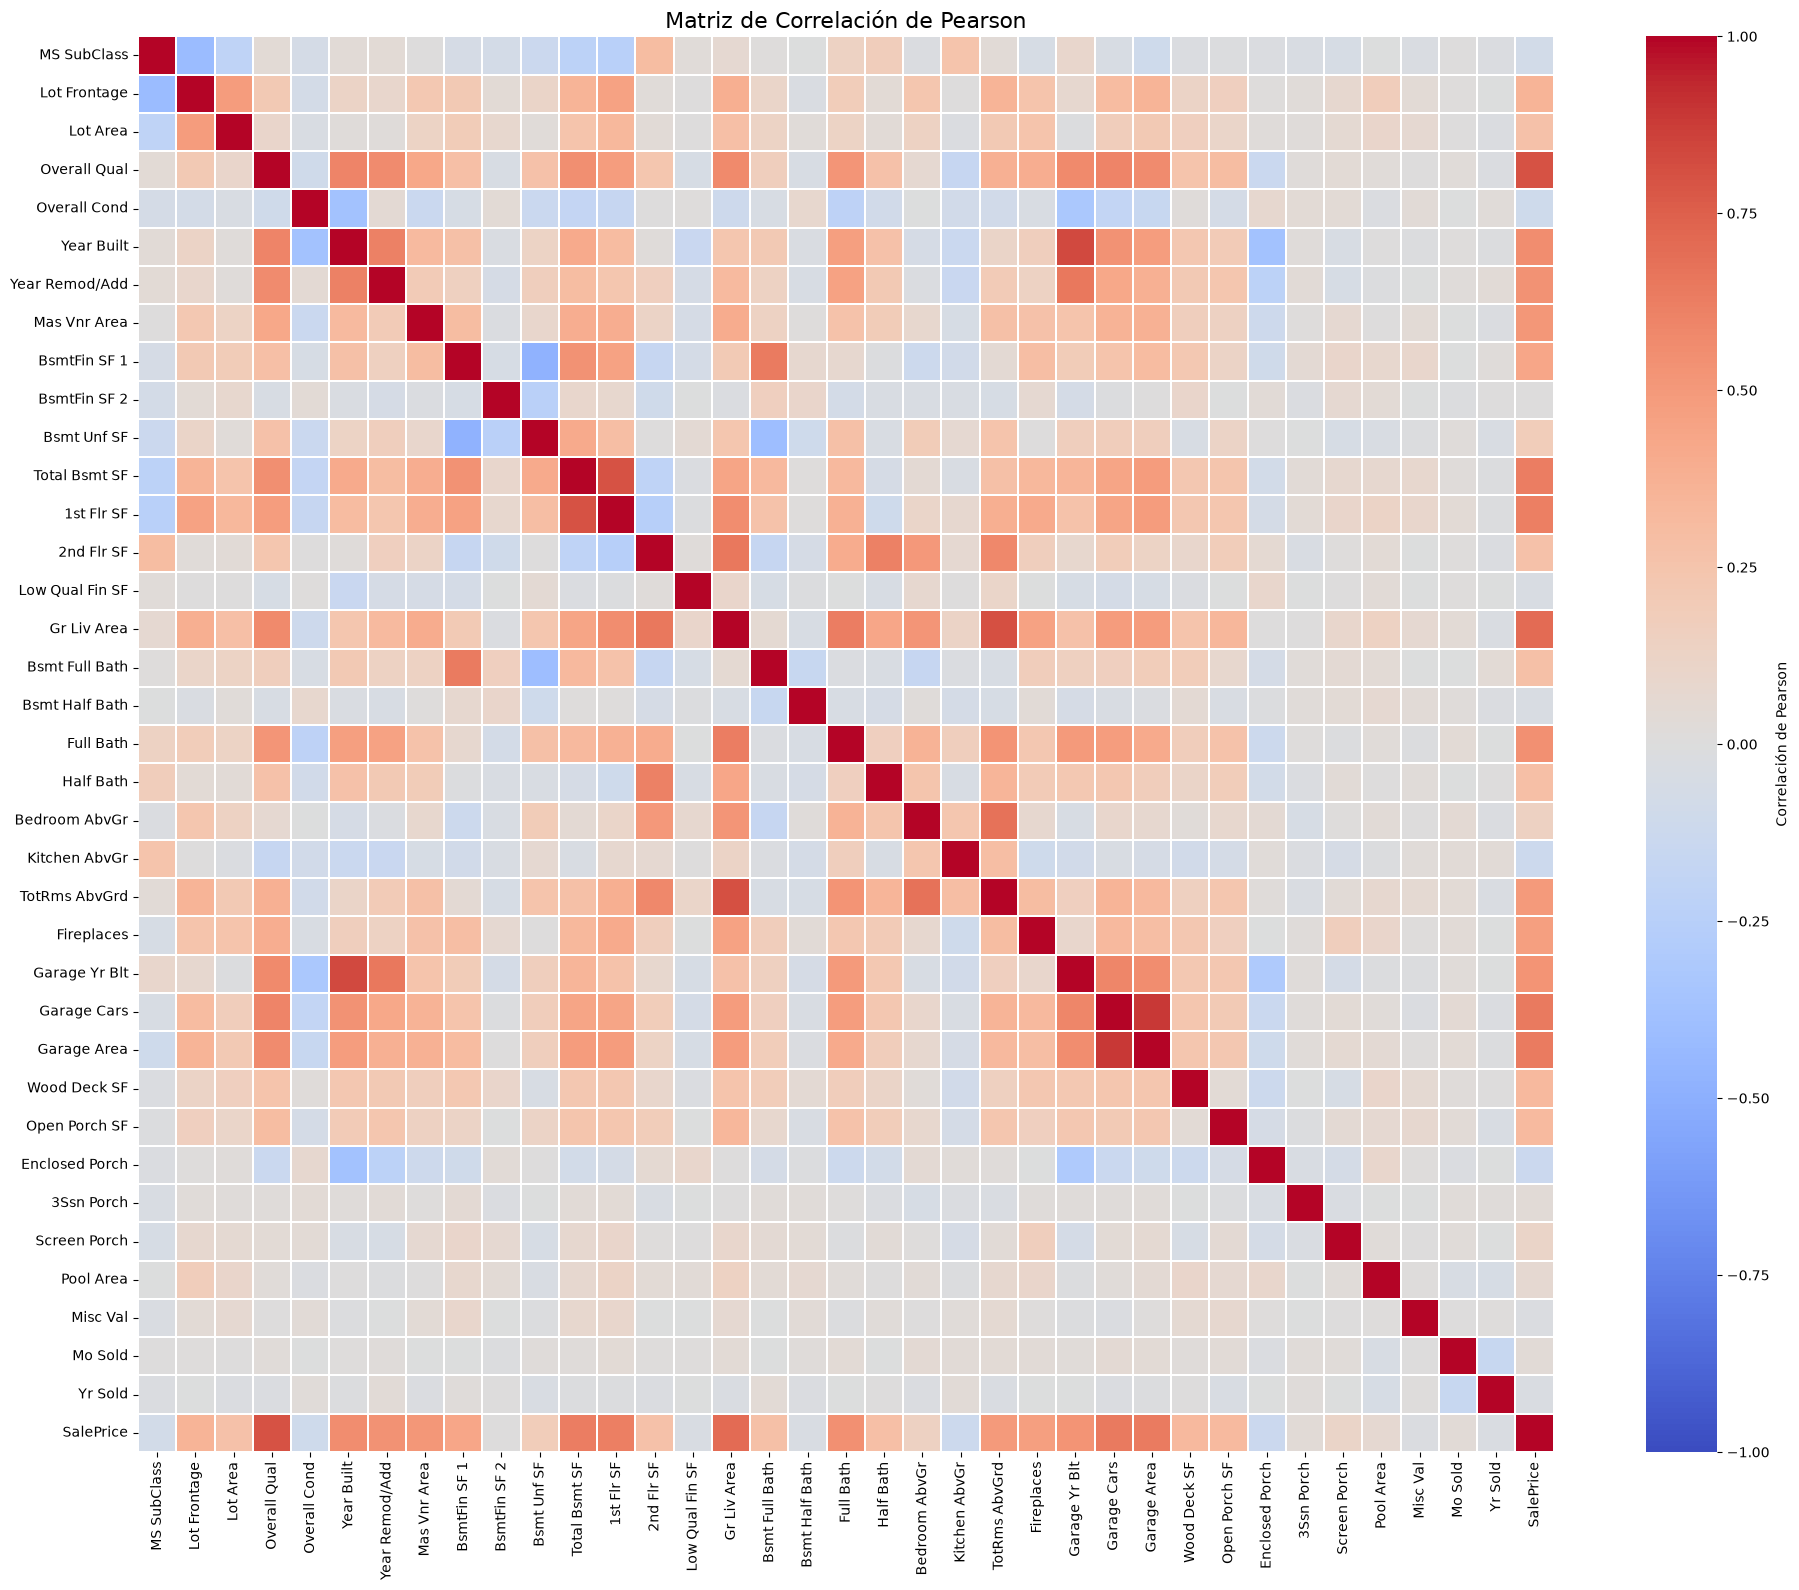

In [11]:
plt.figure(figsize=(20, 16))

sns.heatmap(
    correlacion_pearson,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
    cbar_kws={"label": "Correlación de Pearson"}
)

plt.title("Matriz de Correlación de Pearson", fontsize=16)
plt.tight_layout()

plt.savefig(
    carpeta_figuras / "matriz_correlacion_pearson.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

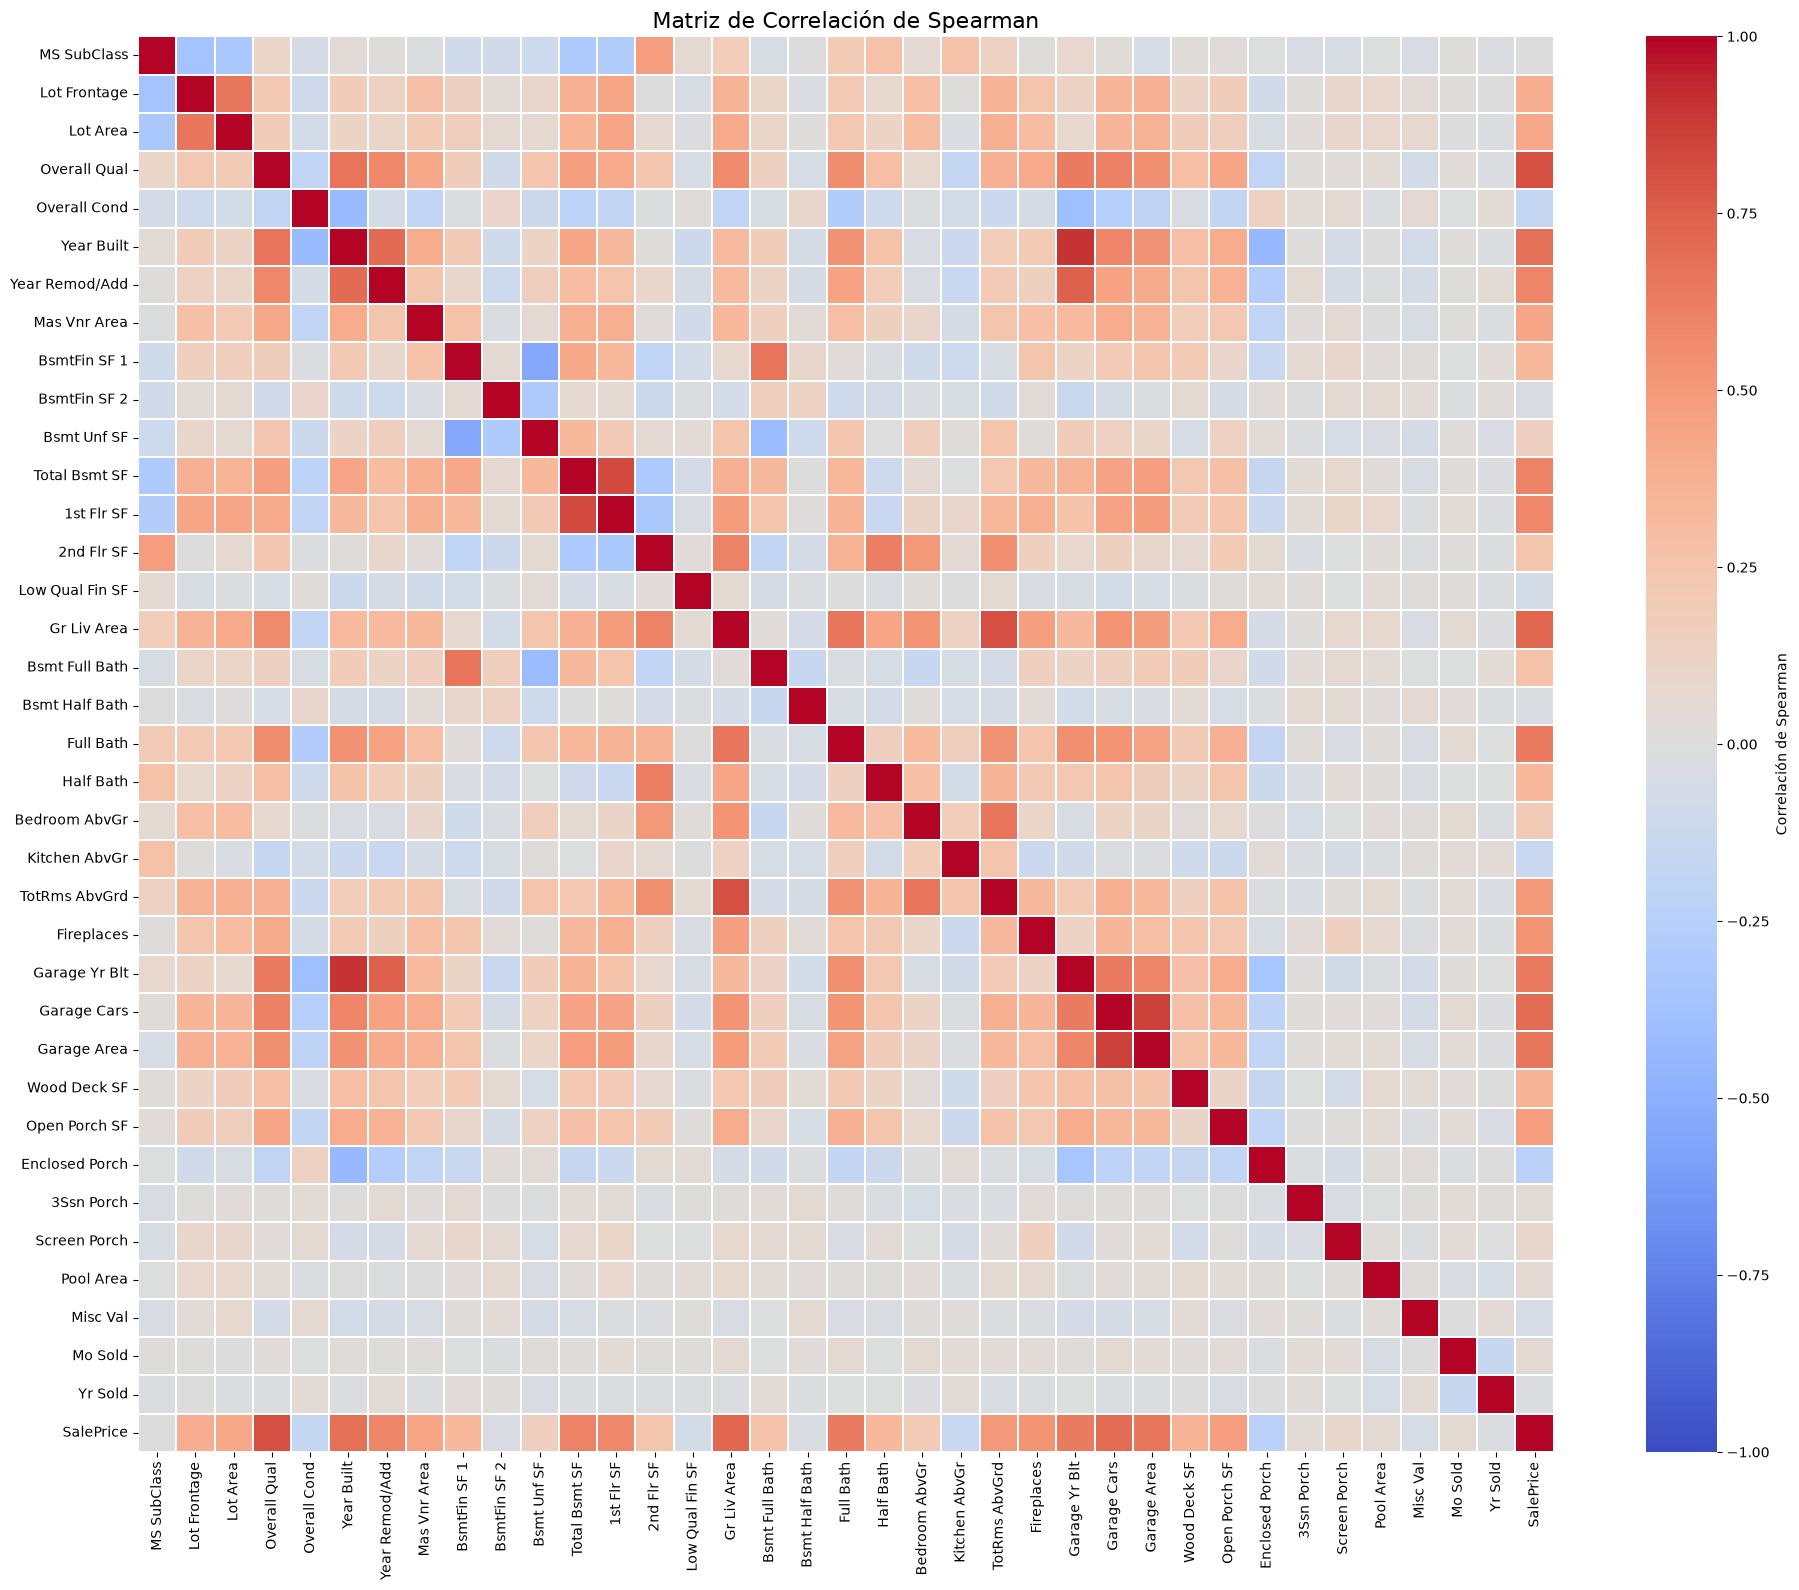

In [12]:
plt.figure(figsize=(20, 16))

sns.heatmap(
    correlacion_spearman,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
    cbar_kws={"label": "Correlación de Spearman"}
)

plt.title("Matriz de Correlación de Spearman", fontsize=16)
plt.tight_layout()

plt.savefig(
    carpeta_figuras / "matriz_correlacion_spearman.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
pearson_saleprice = (
    correlacion_pearson["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=abs, ascending=False)
)

spearman_saleprice = (
    correlacion_spearman["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=abs, ascending=False)
)

print("Top 10 — Pearson con SalePrice")
display(pearson_saleprice.head(10))

print("\nTop 10 — Spearman con SalePrice")
display(spearman_saleprice.head(10))

Top 10 — Pearson con SalePrice


Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64


Top 10 — Spearman con SalePrice


Overall Qual      0.808800
Gr Liv Area       0.723342
Garage Cars       0.701813
Year Built        0.680822
Garage Area       0.660676
Garage Yr Blt     0.637674
Full Bath         0.634161
Total Bsmt SF     0.606184
Year Remod/Add    0.601454
1st Flr SF        0.581536
Name: SalePrice, dtype: float64

## Preguntas de análisis

A partir de la exploración inicial del conjunto de datos, se plantean las siguientes preguntas:

1. ¿Qué variables numéricas presentan una mayor relación con el precio de venta (`SalePrice`) de las viviendas?

2. ¿Cómo se relacionan la calidad general de la vivienda (`Overall Qual`) y el área habitable (`Gr Liv Area`) con el precio de venta?

3. ¿Existen diferencias relevantes entre las correlaciones de Pearson y Spearman respecto a `SalePrice` que sugieran relaciones que no sean estrictamente lineales?

4. ¿Qué variables numéricas presentan distribuciones asimétricas o posibles valores atípicos que deban considerarse durante la limpieza y transformación de los datos?

In [14]:
asimetria = (
    df[columnas_eda]
    .skew()
    .sort_values(key=abs, ascending=False)
)

print("Variables con mayor asimetría:")
display(asimetria.head(10))

Variables con mayor asimetría:


Misc Val           21.999788
Pool Area          16.939142
Lot Area           12.820898
Low Qual Fin SF    12.118162
3Ssn Porch         11.403795
Kitchen AbvGr       4.313825
BsmtFin SF 2        4.139978
Enclosed Porch      4.014446
Screen Porch        3.957467
Bsmt Half Bath      3.940795
dtype: float64

In [15]:
print("Asimetría de SalePrice:", df["SalePrice"].skew())

Asimetría de SalePrice: 1.7435000757376466


In [16]:
resumen_correlaciones = pd.DataFrame({
    "Pearson": correlacion_pearson["SalePrice"].drop("SalePrice"),
    "Spearman": correlacion_spearman["SalePrice"].drop("SalePrice")
})

resumen_correlaciones["Pearson_abs"] = resumen_correlaciones["Pearson"].abs()
resumen_correlaciones = resumen_correlaciones.sort_values(
    "Pearson_abs",
    ascending=False
)

resumen_correlaciones.to_csv(
    "correlaciones_SalePrice.csv",
    index_label="Variable"
)

display(resumen_correlaciones.head(10))

,Pearson,Spearman,Pearson_abs
Overall Qual,0.799262,0.808800,0.799262
Gr Liv Area,0.706780,0.723342,0.706780
Garage Cars,0.647877,0.701813,0.647877
Garage Area,0.640401,0.660676,0.640401
Total Bsmt SF,0.632280,0.606184,0.632280
1st Flr SF,0.621676,0.581536,0.621676
Year Built,0.558426,0.680822,0.558426
Full Bath,0.545604,0.634161,0.545604
Year Remod/Add,0.532974,0.601454,0.532974
Garage Yr Blt,0.526965,0.637674,0.526965


In [17]:
archivos_png = sorted(carpeta_figuras.glob("*.png"))

print("Total de imágenes guardadas:", len(archivos_png))
print("\nArchivos principales:")
print("- matriz_correlacion_pearson.png:",
      (carpeta_figuras / "matriz_correlacion_pearson.png").exists())
print("- matriz_correlacion_spearman.png:",
      (carpeta_figuras / "matriz_correlacion_spearman.png").exists())
print("- correlaciones_SalePrice.csv:",
      Path("correlaciones_SalePrice.csv").exists())

Total de imágenes guardadas: 39

Archivos principales:
- matriz_correlacion_pearson.png: True
- matriz_correlacion_spearman.png: True
- correlaciones_SalePrice.csv: True


## Resultados de la exploración

El análisis de las distribuciones muestra que varias variables numéricas presentan asimetrías importantes. En particular, `Misc Val`, `Pool Area`, `Lot Area`, `Low Qual Fin SF` y `3Ssn Porch` registran los mayores niveles de asimetría. La variable objetivo `SalePrice` presenta una asimetría positiva de 1.7435, lo que indica una concentración de observaciones en precios bajos e intermedios y una cola hacia los valores más altos. Estas características deberán considerarse posteriormente durante el tratamiento de valores atípicos y la transformación de los datos.

En el análisis de correlación de Pearson, las mayores asociaciones positivas con `SalePrice` corresponden a `Overall Qual` (0.7993), `Gr Liv Area` (0.7068) y `Garage Cars` (0.6479). Esto indica que la calidad general, el área habitable sobre el nivel del suelo y la capacidad del garaje presentan relaciones lineales importantes con el precio de venta.

Los resultados de Spearman mantienen un patrón similar. Las variables con mayores asociaciones con `SalePrice` son `Overall Qual` (0.8088), `Gr Liv Area` (0.7233) y `Garage Cars` (0.7018). Las diferencias observadas entre Pearson y Spearman justifican analizar la forma de las relaciones y no asumir que todas son estrictamente lineales.

En conjunto, la exploración inicial permite identificar variables potencialmente relevantes para explicar el precio de venta y distribuciones que requieren atención en las siguientes etapas del preprocesamiento. Estas asociaciones se interpretan como relaciones estadísticas y no como evidencia de causalidad.